In [ ]:
pip install scikit-learn

In [ ]:
pip install matplotlib

In [ ]:
pip install tensorflow-datasets

In [ ]:
pip install tensorflow

In [ ]:
pip install pyheif pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 24.6 MB/s eta 0:00:00


In [ ]:
!pip install keras-cv --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 22.6 MB/s eta 0:00:00


In [ ]:
# Assuming you are using Google Colab...
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
# You may need to change the path to your own directory name
# Reads in Kaggle data
!unzip gdrive/MyDrive/'DS340 Project'/Kaggle_dataset.zip

Archive:  gdrive/MyDrive/DS340 Project/Kaggle_dataset.zip
  inflating: README_rpc-cv-images.txt  
  inflating: paper/04l5I8TqdzF9WDMJ.png  
  inflating: paper/0Og76sl5CJhbxWWx.png  
  inflating: paper/0RA9rcrv8iVvuDDU.png  
  inflating: paper/0Uomd0HvOB33m47I.png  
  inflating: paper/0a3UtNzl5Ll3sq8K.png  
  inflating: paper/0cb6cVL8pkfi4wF6.png  
  inflating: paper/0eqArS2GgsBeqgSn.png  
  inflating: paper/0t08v9bAaA0mXGCQ.png  
  inflating: paper/0vugygEjxQJPr9yz.png  
  inflating: paper/0zKU6wEhT2cDe9j0.png  
  inflating: paper/14K62H4KG1hg5qiJ.png  
  inflating: paper/1Dfw5FRlS4h60JPX.png  
  inflating: paper/1Frbe8cdOdkciOBg.png  
  inflating: paper/1Tt9U9SzrOm98Xtw.png  
  inflating: paper/1fKclJk4eBWOQSR1.png  
  inflating: paper/1jHtb93pI8f6pfKo.png  
  inflating: paper/1oKnUgV2CdCaQUUX.png  
  inflating: paper/1uoW7QcH2qAgCTxv.png  
  inflating: paper/1yKjzquSvl9ShK7K.png  
  inflating: paper/1yeoLbmp4alVOtFv.png  
  inflating: paper/27XFtQjjXQ8AP8Tl.png  
  inflating: paper/2

In [ ]:
!ls /content

gdrive	README_rpc-cv-images.txt  rps-cv-images  scissors
paper	rock			  sample_data


In [ ]:
# You may need to change the path to your own directory name
# Reads in our self collected data
!unzip gdrive/MyDrive/'DS340 Project'/self_collected_data.zip

Archive:  gdrive/MyDrive/DS340 Project/self_collected_data.zip
  inflating: self_collected_data/rock/IMG_7198.JPG  
  inflating: self_collected_data/rock/IMG_7204.JPG  
  inflating: self_collected_data/rock/IMG_7201.JPG  
  inflating: self_collected_data/rock/IMG_7207.JPG  
  inflating: self_collected_data/rock/IMG_9084.HEIC  
  inflating: self_collected_data/rock/IMG_9081.HEIC  
  inflating: self_collected_data/rock/IMG_9083.HEIC  
  inflating: self_collected_data/rock/IMG_9109.HEIC  
  inflating: self_collected_data/rock/IMG_9110.HEIC  
  inflating: self_collected_data/rock/IMG_9080.HEIC  
  inflating: self_collected_data/rock/IMG_9082.HEIC  
  inflating: self_collected_data/rock/IMG_9077.HEIC  
  inflating: self_collected_data/rock/IMG_9072.HEIC  
  inflating: self_collected_data/rock/IMG_9069.HEIC  
  inflating: self_collected_data/rock/IMG_9073.HEIC  
  inflating: self_collected_data/rock/IMG_9071.HEIC  
  inflating: self_collected_data/rock/IMG_9074.HEIC  
  inflating: self_colle

In [ ]:
!ls /content

gdrive	README_rpc-cv-images.txt  rps-cv-images  scissors
paper	rock			  sample_data	 self_collected_data


In [ ]:
# converts our self collected data from HEIC to JPG
def convert_heic_to_jpg(src_folder):
    for filename in os.listdir(src_folder):
        if filename.lower().endswith(".heic"):
            heic_path = os.path.join(src_folder, filename)
            jpg_filename = filename.rsplit(".", 1)[0] + ".jpg"
            jpg_path = os.path.join(src_folder, jpg_filename)

            try:
                heif_file = pyheif.read(heic_path)
                image = Image.frombytes(
                    heif_file.mode, heif_file.size, heif_file.data, "raw", heif_file.mode
                )
                image.save(jpg_path, "JPEG")
                os.remove(heic_path)
                print(f"Converted and deleted HEIC: {filename} -> {jpg_filename}")
            except Exception as e:
                print(f"Failed to convert {filename}: {e}")

In [ ]:
# takes 5 minutes to run
import os
import pyheif
from PIL import Image
base_path = "/content/self_collected_data"

for cls in ["rock", "paper", "scissors"]:
    folder_path = os.path.join(base_path, cls)
    convert_heic_to_jpg(folder_path)

Converted and deleted HEIC: IMG_2922.HEIC -> IMG_2922.jpg
Converted and deleted HEIC: IMG_2916.HEIC -> IMG_2916.jpg
Converted and deleted HEIC: IMG_2593.HEIC -> IMG_2593.jpg
Converted and deleted HEIC: IMG_2954.HEIC -> IMG_2954.jpg
Converted and deleted HEIC: IMG_9073.HEIC -> IMG_9073.jpg
Converted and deleted HEIC: IMG_9077.HEIC -> IMG_9077.jpg
Converted and deleted HEIC: IMG_2911.HEIC -> IMG_2911.jpg
Converted and deleted HEIC: IMG_2871.HEIC -> IMG_2871.jpg
Converted and deleted HEIC: IMG_2918.HEIC -> IMG_2918.jpg
Converted and deleted HEIC: IMG_2914.HEIC -> IMG_2914.jpg
Converted and deleted HEIC: IMG_2903.HEIC -> IMG_2903.jpg
Converted and deleted HEIC: IMG_2560.HEIC -> IMG_2560.jpg
Converted and deleted HEIC: IMG_9076.HEIC -> IMG_9076.jpg
Converted and deleted HEIC: IMG_9084.HEIC -> IMG_9084.jpg
Converted and deleted HEIC: IMG_2555.HEIC -> IMG_2555.jpg
Converted and deleted HEIC: IMG_2559.HEIC -> IMG_2559.jpg
Converted and deleted HEIC: IMG_2906.HEIC -> IMG_2906.jpg
Converted and 

# Using Only Clean Kaggle Data to Train & Use Self Collected to Test

In [ ]:
data_dir = "rps-cv-images"

for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)
    if os.path.isdir(class_path):
        num_images = len([
            fname for fname in os.listdir(class_path)
            if fname.lower().endswith(('.jpg', '.jpeg', '.png', '.heic'))
        ])
        print(f"{class_name}: {num_images} images")

scissors: 750 images
rock: 726 images
paper: 712 images


In [ ]:
import tensorflow as tf
import keras_cv

batch_size = 32
img_size = (122, 122)

# Data from https://www.kaggle.com/datasets/drgfreeman/rockpaperscissors
train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/rps-cv-images",
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=img_size,
    batch_size=batch_size)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/rps-cv-images",
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=img_size,
    batch_size=batch_size)

#Use Self-collected data to test
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/self_collected_data",
    image_size=(122, 122),
    batch_size=32)


Found 2188 files belonging to 3 classes.
Using 1751 files for training.
Found 2188 files belonging to 3 classes.
Using 437 files for validation.
Found 288 files belonging to 3 classes.


In [ ]:
#check how many images are in each folder
data_dir = "self_collected_data"

for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)
    if os.path.isdir(class_path):
        num_images = len([
            fname for fname in os.listdir(class_path)
            if fname.lower().endswith(('.jpg', '.jpeg', '.png', '.heic'))
        ])
        print(f"{class_name}: {num_images} images")

scissors: 95 images
rock: 92 images
paper: 101 images


In [ ]:
# check class names
print("Class names:", train_ds.class_names)

Class names: ['paper', 'rock', 'scissors']


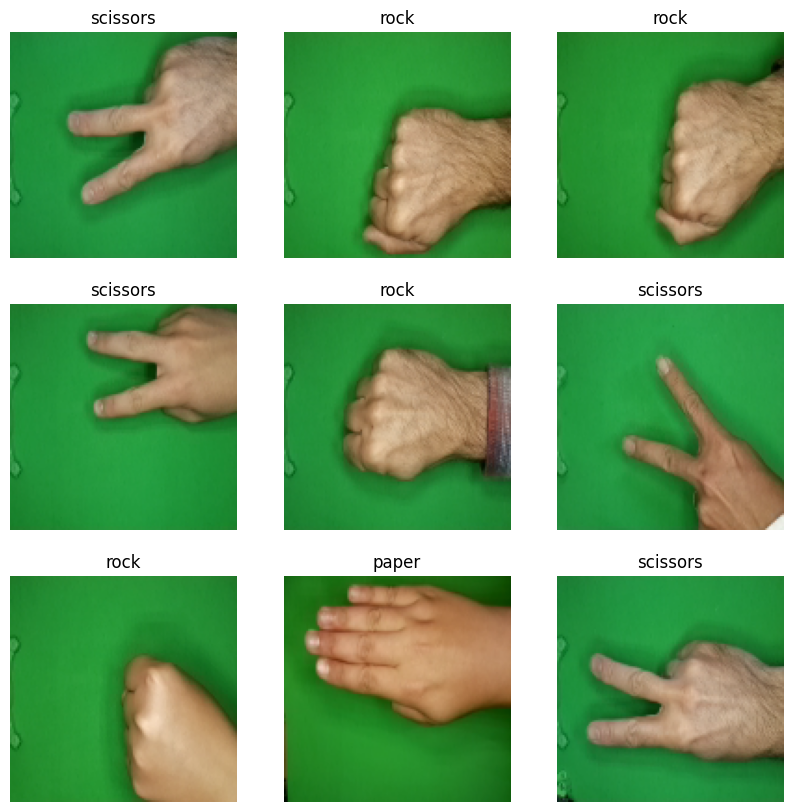

In [ ]:
import matplotlib.pyplot as plt

class_names = train_ds.class_names  # ['rock', 'paper', 'scissors']

# Get one batch of images and labels from train(kaggle dataset)
for images, labels in train_ds.take(1):
    plt.figure(figsize=(10, 10))
    for i in range(9):  # Show first 9 images
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

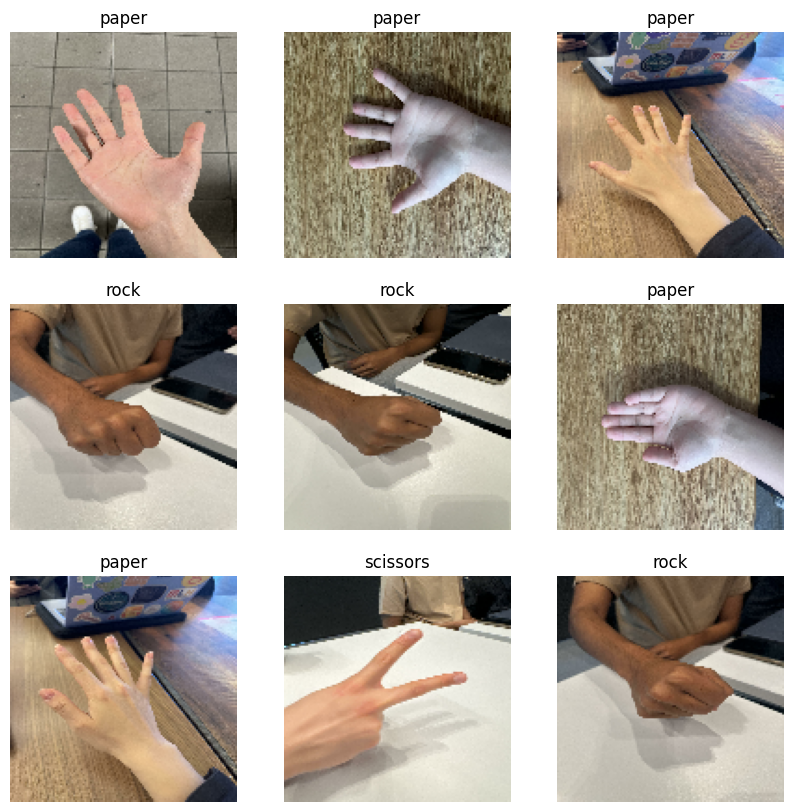

In [ ]:
class_names = test_ds.class_names  # ['rock', 'paper', 'scissors']

# Get one batch of images and labels from test(self collected data)
for images, labels in test_ds.take(1):
    plt.figure(figsize=(10, 10))
    for i in range(9):  # Show first 9 images
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

## Baseline CNN

In [ ]:
from tensorflow.keras import layers, models
import tensorflow as tf
from tensorflow import keras
input_shape = (122,122,3)

# Baseline CNN Model
model = keras.Sequential([
    keras.Input(shape=input_shape),
    layers.Rescaling(1./255, input_shape=input_shape),
    layers.RandomRotation(0.2),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1),

    layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')  # 3 classes
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
epochs = 20

model.compile(loss='sparse_categorical_crossentropy', optimizer="adam", metrics=["accuracy"])
callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)] # Quit after 3 rounds of no validation loss improvement
model.fit(train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks)

Epoch 1/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.4023 - loss: 1.1164 - val_accuracy: 0.7254 - val_loss: 0.7974
Epoch 2/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.6770 - loss: 0.7898 - val_accuracy: 0.8741 - val_loss: 0.3715
Epoch 3/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.7971 - loss: 0.5200 - val_accuracy: 0.8375 - val_loss: 0.4829
Epoch 4/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.8251 - loss: 0.4276 - val_accuracy: 0.8902 - val_loss: 0.3126
Epoch 5/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.8730 - loss: 0.3449 - val_accuracy: 0.9291 - val_loss: 0.2063
Epoch 6/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.8886 - loss: 0.3107 - val_accuracy: 0.8604 - val_loss: 0.3369
Epoch 7/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.8995 - loss: 0.2703 - val_accuracy: 0.9634 - val_loss: 0.1456
Epoch 8/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step - accuracy: 0.9270 - loss: 0.2205 - val_accuracy: 0.9588 - val_loss

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 895ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 493ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 716ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 708ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 554ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 581ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 531ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 528ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step


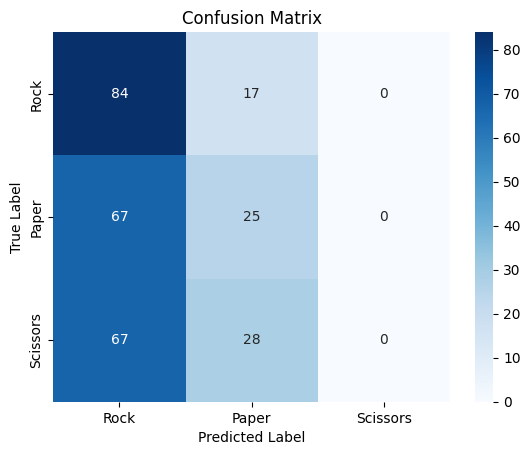

Accuracy: 0.3784722222222222

Classification Report:
               precision    recall  f1-score   support

        Rock       0.39      0.83      0.53       101
       Paper       0.36      0.27      0.31        92
    Scissors       0.00      0.00      0.00        95

    accuracy                           0.38       288
   macro avg       0.25      0.37      0.28       288
weighted avg       0.25      0.38      0.28       288



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Rock", "Paper", "Scissors"], yticklabels=["Rock", "Paper", "Scissors"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

print("Accuracy:", accuracy_score(y_true, y_pred))
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=["Rock", "Paper", "Scissors"]))


In [ ]:
# Baseline CNN Model 2
# Use a new learning rate
model = keras.Sequential([
    keras.Input(shape=input_shape),
    layers.Rescaling(1./255, input_shape=input_shape), # normalize pixel values
    layers.RandomRotation(0.2),
    layers.RandomFlip("horizontal"),                           #add horizontal flip
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1),

    layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')  # 3 classes
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
from tensorflow.keras import optimizers
epochs = 10

model.compile(loss='sparse_categorical_crossentropy', optimizer=optimizers.Adam(learning_rate=0.0005), metrics=["accuracy"])
callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)] # Quit after 3 rounds of no validation loss improvement
model.fit(train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks)

Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.3810 - loss: 1.0997 - val_accuracy: 0.4783 - val_loss: 0.9582
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.5731 - loss: 0.9153 - val_accuracy: 0.8421 - val_loss: 0.6668
Epoch 3/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.7595 - loss: 0.6565 - val_accuracy: 0.9130 - val_loss: 0.3415
Epoch 4/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.8371 - loss: 0.4415 - val_accuracy: 0.9359 - val_loss: 0.2547
Epoch 5/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.9249 - loss: 0.2753 - val_accuracy: 0.9245 - val_loss: 0.2280
Epoch 6/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.9260 - loss: 0.2324 - val_accuracy: 0.9634 - val_loss: 0.1223
Epoch 7/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.9220 - loss: 0.2277 - val_accuracy: 0.9359 - val_loss: 0.1667
Epoch 8/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.9485 - loss: 0.1638 - val_accuracy: 0.9725 - val_loss:

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 535ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 507ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 582ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 537ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 600ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 802ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 543ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step


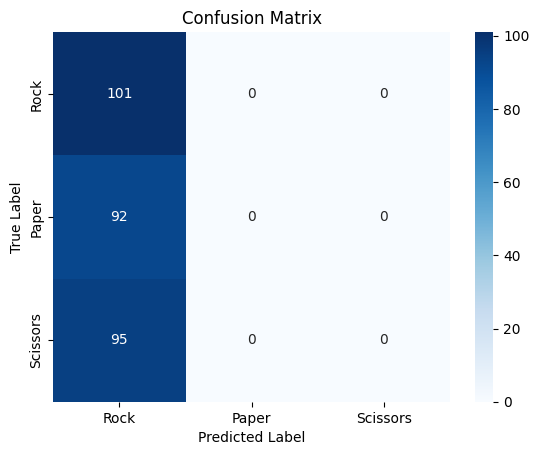

Accuracy: 0.3506944444444444

Classification Report:
               precision    recall  f1-score   support

        Rock       0.35      1.00      0.52       101
       Paper       0.00      0.00      0.00        92
    Scissors       0.00      0.00      0.00        95

    accuracy                           0.35       288
   macro avg       0.12      0.33      0.17       288
weighted avg       0.12      0.35      0.18       288



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)


cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Rock", "Paper", "Scissors"], yticklabels=["Rock", "Paper", "Scissors"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

print("Accuracy:", accuracy_score(y_true, y_pred))
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=["Rock", "Paper", "Scissors"]))

## Use ResNet to Train on Kaggle Data & Test on Self-Collected Data

In [ ]:
# Try ResNet
# Load ResNet-50 model
resnet50 = keras.applications.ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(122, 122, 3)  # Adjust to your image size
)

resnet50.trainable = False

# Build the full model
model_res =tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    resnet50,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(3, activation="softmax")
])

model_res.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Set up EarlyStopping callback
callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=2)]

model_res.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=callbacks)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 157s 3s/step - accuracy: 0.8253 - loss: 0.4870 - val_accuracy: 0.9657 - val_loss: 0.1217
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 199s 3s/step - accuracy: 0.9727 - loss: 0.0651 - val_accuracy: 0.9817 - val_loss: 0.0479
Epoch 3/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 202s 3s/step - accuracy: 0.9770 - loss: 0.0585 - val_accuracy: 0.9817 - val_loss: 0.0635
Epoch 4/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 144s 3s/step - accuracy: 0.9833 - loss: 0.0518 - val_accuracy: 0.9886 - val_loss: 0.0349
Epoch 5/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 202s 3s/step - accuracy: 0.9860 - loss: 0.0371 - val_accuracy: 0.9794 - val_loss: 0.0535
Epoch 6/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 144s 3s/step - accuracy: 0.9905 - loss: 0.0321 - val_accuracy: 0.9908 - val_loss: 0.0173
Epoch 7/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 202s 3s/step - accuracy: 0.9924 - loss: 0.0287 - val_accuracy: 0.9817 - val_loss: 0.0407
Epoch 8/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 203s 3s/step - accura

1/1 ━━━━━━━━━━━━━━━━━━━━ 18s 18s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


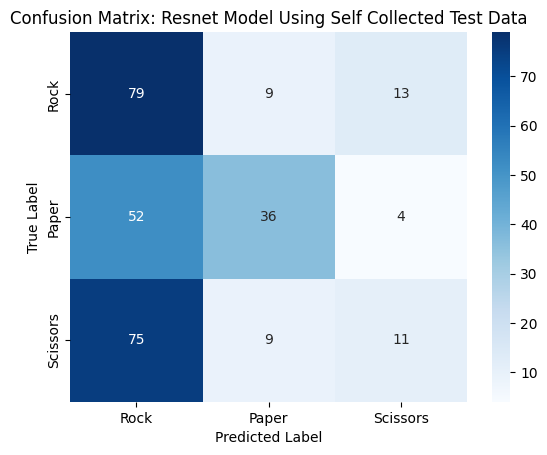

Accuracy: 0.4375

Classification Report:
               precision    recall  f1-score   support

        Rock       0.38      0.78      0.51       101
       Paper       0.67      0.39      0.49        92
    Scissors       0.39      0.12      0.18        95

    accuracy                           0.44       288
   macro avg       0.48      0.43      0.40       288
weighted avg       0.48      0.44      0.40       288



In [ ]:
y_true_res = []
y_pred_res = []

for images, labels in test_ds:
    preds = model_res.predict(images)
    y_true_res.extend(labels.numpy())
    y_pred_res.extend(np.argmax(preds, axis=1))

y_true_res = np.array(y_true_res)
y_pred_res = np.array(y_pred_res)


cm = confusion_matrix(y_true_res, y_pred_res)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Rock", "Paper", "Scissors"], yticklabels=["Rock", "Paper", "Scissors"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix: Resnet Model Using Self Collected Test Data")
plt.show()

print("Accuracy:", accuracy_score(y_true_res, y_pred_res))
print("\nClassification Report:\n", classification_report(y_true_res, y_pred_res, target_names=["Rock", "Paper", "Scissors"]))

## Use EfficientNetB0 to Train on Kaggle Data & Test on Self Collected Data


In [ ]:
from tensorflow.keras.applications import EfficientNetB0

efficientnet_base_model = EfficientNetB0(input_shape=(122, 122, 3), include_top=False, weights='imagenet')

efficientnet_base_model.trainable = False

efficientnet_model = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    efficientnet_base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(3, activation="softmax")
    ])

efficientnet_model.compile(optimizer="adam",loss='sparse_categorical_crossentropy', metrics=['accuracy'])

callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)]

efficientnet_model.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=callbacks)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 69s 996ms/step - accuracy: 0.8487 - loss: 0.3824 - val_accuracy: 0.9748 - val_loss: 0.0733
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 79s 940ms/step - accuracy: 0.9807 - loss: 0.0520 - val_accuracy: 0.9748 - val_loss: 0.0693
Epoch 3/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 82s 943ms/step - accuracy: 0.9891 - loss: 0.0326 - val_accuracy: 0.9817 - val_loss: 0.0458
Epoch 4/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 82s 944ms/step - accuracy: 0.9967 - loss: 0.0192 - val_accuracy: 0.9703 - val_loss: 0.0802
Epoch 5/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 82s 937ms/step - accuracy: 0.9941 - loss: 0.0197 - val_accuracy: 0.9886 - val_loss: 0.0355
Epoch 6/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 82s 939ms/step - accuracy: 0.9948 - loss: 0.0175 - val_accuracy: 0.9931 - val_loss: 0.0149
Epoch 7/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 52s 950ms/step - accuracy: 0.9961 - loss: 0.0193 - val_accuracy: 0.9886 - val_loss: 0.0351
Epoch 8/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 52s 932m

1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 596ms/step


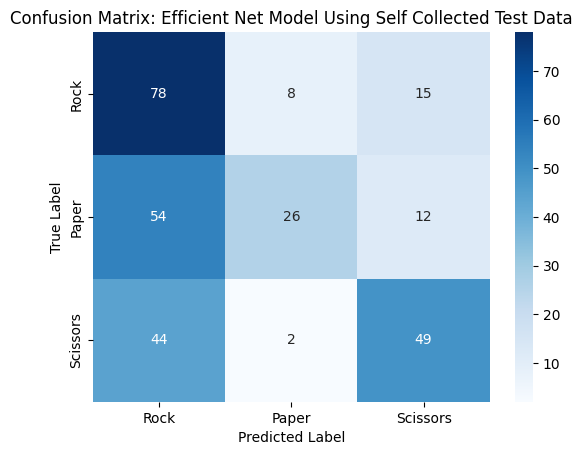

Accuracy: 0.53125

Classification Report:
               precision    recall  f1-score   support

        Rock       0.44      0.77      0.56       101
       Paper       0.72      0.28      0.41        92
    Scissors       0.64      0.52      0.57        95

    accuracy                           0.53       288
   macro avg       0.60      0.52      0.51       288
weighted avg       0.60      0.53      0.52       288



In [ ]:
# Evaluate
y_true_effnet = []
y_pred_effnet = []

for images, labels in test_ds:
    preds = efficientnet_model.predict(images)
    y_true_effnet.extend(labels.numpy())
    y_pred_effnet.extend(np.argmax(preds, axis=1))

y_true_effnet = np.array(y_true_effnet)
y_pred_effnet = np.array(y_pred_effnet)


cm = confusion_matrix(y_true_effnet, y_pred_effnet)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Rock", "Paper", "Scissors"], yticklabels=["Rock", "Paper", "Scissors"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix: Efficient Net Model Using Self Collected Test Data")
plt.show()

print("Accuracy:", accuracy_score(y_true_effnet, y_pred_effnet))
print("\nClassification Report:\n", classification_report(y_true_effnet, y_pred_effnet, target_names=["Rock", "Paper", "Scissors"]))

# Train & Test Using the Self Collected Data

In [ ]:
import tensorflow as tf
import keras_cv

batch_size = 32
img_size = (122, 122)

#self collected data
train_ds_es = tf.keras.utils.image_dataset_from_directory(
    "/content/self_collected_data",
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=img_size,
    batch_size=batch_size)

val_ds_es = tf.keras.utils.image_dataset_from_directory(
    "/content/self_collected_data",
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=img_size,
    batch_size=batch_size)

Found 288 files belonging to 3 classes.
Using 231 files for training.
Found 288 files belonging to 3 classes.
Using 57 files for validation.


In [ ]:
# Try ResNet
# Load ResNet-50 model
resnet50 = keras.applications.ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(122, 122, 3)  # Adjust to your image size
)

resnet50.trainable = False

model_res =tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    resnet50,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(3, activation="softmax")
])

model_res.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=2)]

model_res.fit(train_ds_es, validation_data=val_ds_es, epochs=10, callbacks=callbacks)

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 52s 5s/step - accuracy: 0.3310 - loss: 2.1808 - val_accuracy: 0.6140 - val_loss: 0.8706
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 40s 5s/step - accuracy: 0.5694 - loss: 0.9380 - val_accuracy: 0.6140 - val_loss: 0.7626
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 41s 5s/step - accuracy: 0.6970 - loss: 0.6848 - val_accuracy: 0.6667 - val_loss: 0.7169
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 37s 4s/step - accuracy: 0.7688 - loss: 0.5744 - val_accuracy: 0.6842 - val_loss: 0.6440
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 41s 4s/step - accuracy: 0.7725 - loss: 0.5535 - val_accuracy: 0.6842 - val_loss: 0.6959
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 45s 5s/step - accuracy: 0.7653 - loss: 0.5069 - val_accuracy: 0.6667 - val_loss: 0.6547


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


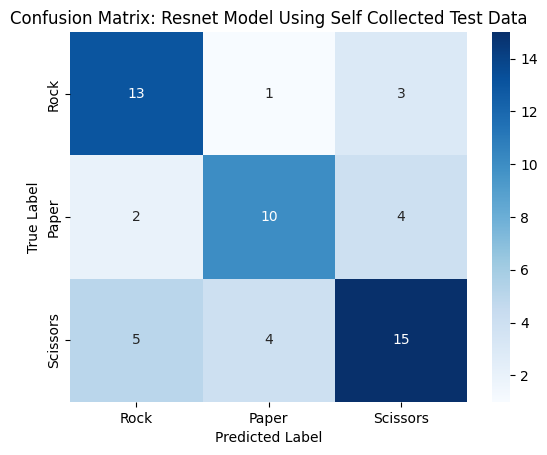

Accuracy: 0.6666666666666666

Classification Report:
               precision    recall  f1-score   support

        Rock       0.65      0.76      0.70        17
       Paper       0.67      0.62      0.65        16
    Scissors       0.68      0.62      0.65        24

    accuracy                           0.67        57
   macro avg       0.67      0.67      0.67        57
weighted avg       0.67      0.67      0.67        57



In [ ]:
y_true_res = []
y_pred_res = []

for images, labels in val_ds_es:
    preds = model_res.predict(images)
    y_true_res.extend(labels.numpy())
    y_pred_res.extend(np.argmax(preds, axis=1))

y_true_res = np.array(y_true_res)
y_pred_res = np.array(y_pred_res)

cm = confusion_matrix(y_true_res, y_pred_res)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Rock", "Paper", "Scissors"], yticklabels=["Rock", "Paper", "Scissors"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix: Resnet Model Using Self Collected Test Data")
plt.show()

print("Accuracy:", accuracy_score(y_true_res, y_pred_res))
print("\nClassification Report:\n", classification_report(y_true_res, y_pred_res, target_names=["Rock", "Paper", "Scissors"]))

In [ ]:
from tensorflow.keras.applications import EfficientNetB0

efficientnet_base_model_2 = EfficientNetB0(input_shape=(122, 122, 3), include_top=False, weights='imagenet')

efficientnet_base_model_2.trainable = False

efficientnet_model_2 = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    efficientnet_base_model_2,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(3, activation="softmax")
    ])

efficientnet_model_2.compile(optimizer="adam",loss='sparse_categorical_crossentropy', metrics=['accuracy'])

callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)]
efficientnet_model_2.fit(train_ds_es, validation_data=val_ds_es, epochs=10, callbacks=callbacks)

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 49s 4s/step - accuracy: 0.3446 - loss: 1.1619 - val_accuracy: 0.7018 - val_loss: 0.8365
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 37s 4s/step - accuracy: 0.6865 - loss: 0.7351 - val_accuracy: 0.6316 - val_loss: 0.7464
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 37s 3s/step - accuracy: 0.8024 - loss: 0.5598 - val_accuracy: 0.7368 - val_loss: 0.6200
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 38s 3s/step - accuracy: 0.7956 - loss: 0.5044 - val_accuracy: 0.7719 - val_loss: 0.5594
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 44s 3s/step - accuracy: 0.8023 - loss: 0.4741 - val_accuracy: 0.7895 - val_loss: 0.5429
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.8419 - loss: 0.3987 - val_accuracy: 0.8246 - val_loss: 0.4463
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 42s 3s/step - accuracy: 0.8510 - loss: 0.3496 - val_accuracy: 0.8070 - val_loss: 0.4407
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 46s 4s/step - accuracy: 0.8557 - loss: 0.3477 - val_accuracy: 0.8246 - val_loss: 0.4111
Epoch 9/

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step


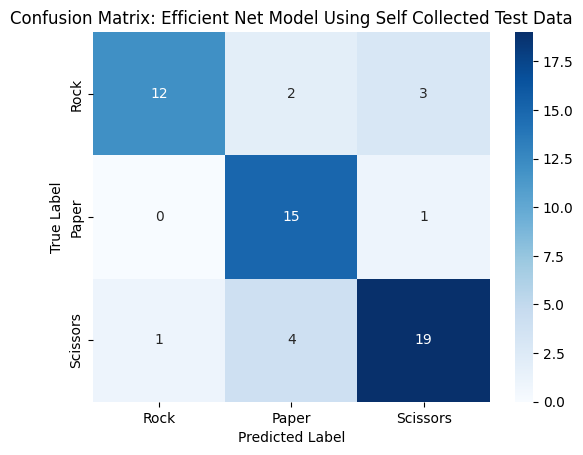

Accuracy: 0.8070175438596491

Classification Report:
               precision    recall  f1-score   support

        Rock       0.92      0.71      0.80        17
       Paper       0.71      0.94      0.81        16
    Scissors       0.83      0.79      0.81        24

    accuracy                           0.81        57
   macro avg       0.82      0.81      0.81        57
weighted avg       0.82      0.81      0.81        57



In [ ]:
y_true_effnet = []
y_pred_effnet = []

for images, labels in val_ds_es:
    preds = efficientnet_model_2.predict(images)
    y_true_effnet.extend(labels.numpy())
    y_pred_effnet.extend(np.argmax(preds, axis=1))

y_true_effnet = np.array(y_true_effnet)
y_pred_effnet = np.array(y_pred_effnet)


cm = confusion_matrix(y_true_effnet, y_pred_effnet)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Rock", "Paper", "Scissors"], yticklabels=["Rock", "Paper", "Scissors"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix: Efficient Net Model Using Self Collected Test Data")
plt.show()

print("Accuracy:", accuracy_score(y_true_effnet, y_pred_effnet))
print("\nClassification Report:\n", classification_report(y_true_effnet, y_pred_effnet, target_names=["Rock", "Paper", "Scissors"]))

# Use a mix of Self-Collected data and Kaggle data in training and Test Set

In [ ]:
from sklearn.model_selection import train_test_split
import os, shutil

def split_data(source_dir, dest_root, split=(0.7, 0.15, 0.15), seed=42):
    classes = ['rock', 'paper', 'scissors']
    for cls in classes:
        cls_path = os.path.join(source_dir, cls)
        images = [os.path.join(cls_path, img) for img in os.listdir(cls_path) if img.lower().endswith(('.jpg', '.jpeg', '.png'))]

        train, temp = train_test_split(images, test_size=(1 - split[0]), random_state=seed)
        val, test = train_test_split(temp, test_size=split[2]/(split[1]+split[2]), random_state=seed)

        for split_name, split_files in zip(['train', 'val', 'test'], [train, val, test]):
            out_dir = os.path.join(dest_root, split_name, cls)
            os.makedirs(out_dir, exist_ok=True)
            for f in split_files:
                shutil.copy(f, os.path.join(out_dir, os.path.basename(f)))

split_data("/content/rps-cv-images", "/content/rps-kaggle-split")
split_data("/content/self_collected_data", "/content/rps-self-split")

In [ ]:
def merge_splits(source1, source2, dest):
    for split in ['train', 'val', 'test']:
        for cls in ['rock', 'paper', 'scissors']:
            dest_dir = os.path.join(dest, split, cls)
            os.makedirs(dest_dir, exist_ok=True)

            for src in [source1, source2]:
                src_dir = os.path.join(src, split, cls)
                if os.path.exists(src_dir):
                    for f in os.listdir(src_dir):
                        shutil.copy(os.path.join(src_dir, f), os.path.join(dest_dir, f))

merge_splits("/content/rps-kaggle-split", "/content/rps-self-split", "/content/rps-combined")

In [ ]:
train_ds_mix = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/rps-combined/train",
    image_size=(122, 122),
    batch_size=32
)

val_ds_mix = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/rps-combined/val",
    image_size=(122, 122),
    batch_size=32
)

test_ds_mix = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/rps-combined/test",
    image_size=(122, 122),
    batch_size=32
)

Found 1730 files belonging to 3 classes.
Found 372 files belonging to 3 classes.
Found 374 files belonging to 3 classes.


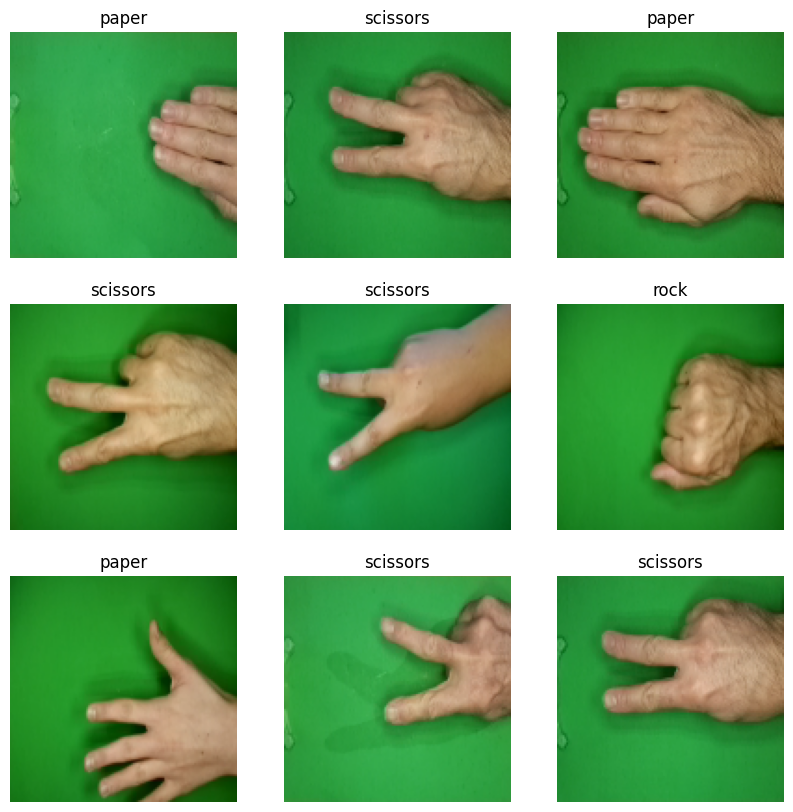

In [ ]:
class_names = train_ds_mix.class_names  # ['rock', 'paper', 'scissors']

for images, labels in train_ds_mix.take(1):
    plt.figure(figsize=(10, 10))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [ ]:
input_shape = (122,122,3)

model_mix = keras.Sequential([
    keras.Input(shape=input_shape),
    layers.Rescaling(1./255, input_shape=input_shape),
    layers.RandomRotation(0.2),
    layers.RandomBrightness(factor=0.2),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1),

    layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')  # 3 classes
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
epochs = 20

model_mix.compile(loss='sparse_categorical_crossentropy', optimizer="adam", metrics=["accuracy"])
callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)]
model_mix.fit(train_ds_mix, epochs=epochs, validation_data=val_ds_mix, callbacks=callbacks)

Epoch 1/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.3291 - loss: 3.8913 - val_accuracy: 0.3414 - val_loss: 1.0979
Epoch 2/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.3480 - loss: 1.1047 - val_accuracy: 0.3280 - val_loss: 1.0990
Epoch 3/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step - accuracy: 0.3429 - loss: 1.0989 - val_accuracy: 0.3414 - val_loss: 1.0985
Epoch 4/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 153s 2s/step - accuracy: 0.3438 - loss: 1.0983 - val_accuracy: 0.3414 - val_loss: 1.0985


12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 511ms/step - accuracy: 0.3529 - loss: 1.0982
test_accuracy: 0.342
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 750ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 587ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 673ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 548ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 535ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 541ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step


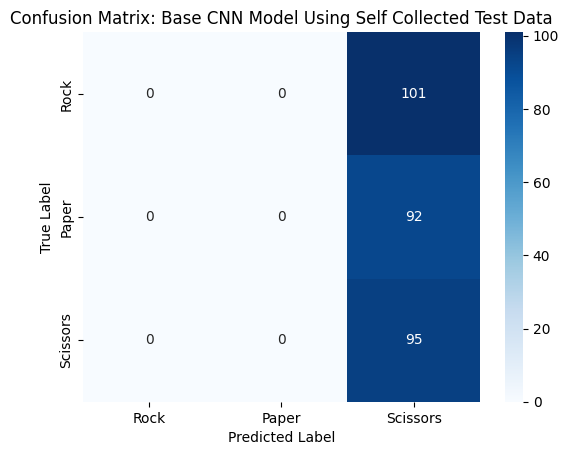

Accuracy: 0.3298611111111111

Classification Report:
               precision    recall  f1-score   support

        Rock       0.00      0.00      0.00       101
       Paper       0.00      0.00      0.00        92
    Scissors       0.33      1.00      0.50        95

    accuracy                           0.33       288
   macro avg       0.11      0.33      0.17       288
weighted avg       0.11      0.33      0.16       288



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
test_loss_base_mix, test_acc_base_mix = model_mix.evaluate(test_ds_mix)
print(f"test_accuracy: {test_acc_base_mix :.3f}")

y_true_base_mix = []
y_pred_base_mix = []

for images, labels in test_ds:
    preds = model_mix.predict(images)
    y_true_base_mix.extend(labels.numpy())
    y_pred_base_mix.extend(np.argmax(preds, axis=1))

y_true_base_mix = np.array(y_true_base_mix)
y_pred_base_mix = np.array(y_pred_base_mix)

cm = confusion_matrix(y_true_base_mix, y_pred_base_mix)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Rock", "Paper", "Scissors"], yticklabels=["Rock", "Paper", "Scissors"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix: Base CNN Model Using Self Collected Test Data")
plt.show()

print("Accuracy:", accuracy_score(y_true_base_mix, y_pred_base_mix))
print("\nClassification Report:\n", classification_report(y_true_base_mix, y_pred_base_mix, target_names=["Rock", "Paper", "Scissors"]))

In [ ]:
# Load ResNet-50 base model
resnet50 = keras.applications.ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(122, 122, 3)  # Adjust to your image size
)

resnet50.trainable = False

model_res =tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    resnet50,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(3, activation="softmax")
])

model_res.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)]

model_res.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=callbacks)

Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 458s 8s/step - accuracy: 0.6865 - loss: 0.7684 - val_accuracy: 0.9301 - val_loss: 0.1432
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 486s 8s/step - accuracy: 0.9397 - loss: 0.1604 - val_accuracy: 0.9597 - val_loss: 0.0973
Epoch 3/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 440s 8s/step - accuracy: 0.9555 - loss: 0.1244 - val_accuracy: 0.9677 - val_loss: 0.0777
Epoch 4/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 427s 8s/step - accuracy: 0.9612 - loss: 0.1091 - val_accuracy: 0.9704 - val_loss: 0.0710
Epoch 5/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 449s 8s/step - accuracy: 0.9533 - loss: 0.1109 - val_accuracy: 0.9624 - val_loss: 0.0774
Epoch 6/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 430s 8s/step - accuracy: 0.9687 - loss: 0.0742 - val_accuracy: 0.9409 - val_loss: 0.1028
Epoch 7/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 452s 8s/step - accuracy: 0.9582 - loss: 0.1256 - val_accuracy: 0.9651 - val_loss: 0.0751


12/12 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.9553 - loss: 0.1209
test_accuracy: 0.949
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


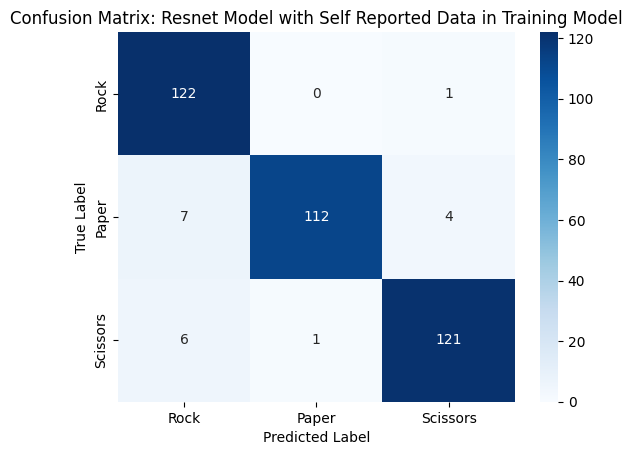

Accuracy: 0.9491978609625669

Classification Report:
               precision    recall  f1-score   support

        Rock       0.90      0.99      0.95       123
       Paper       0.99      0.91      0.95       123
    Scissors       0.96      0.95      0.95       128

    accuracy                           0.95       374
   macro avg       0.95      0.95      0.95       374
weighted avg       0.95      0.95      0.95       374



In [ ]:
test_loss_mix, test_acc_mix = model_res.evaluate(test_ds_mix)
print(f"test_accuracy: {test_acc_mix :.3f}")

y_true_res_mix = []
y_pred_res_mix = []

for images, labels in test_ds_mix:
    preds = model_res.predict(images)
    y_true_res_mix.extend(labels.numpy())
    y_pred_res_mix.extend(np.argmax(preds, axis=1))

y_true_res_mix = np.array(y_true_res_mix)
y_pred_res_mix = np.array(y_pred_res_mix)


cm = confusion_matrix(y_true_res_mix, y_pred_res_mix)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Rock", "Paper", "Scissors"], yticklabels=["Rock", "Paper", "Scissors"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix: Resnet Model with Self Reported Data in Training Model")
plt.show()

print("Accuracy:", accuracy_score(y_true_res_mix, y_pred_res_mix))
print("\nClassification Report:\n", classification_report(y_true_res_mix, y_pred_res_mix, target_names=["Rock", "Paper", "Scissors"]))